<a href="https://colab.research.google.com/github/hardiksharma2005/Datacouch-assignment/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Customer Analytics: Churn

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import warnings
import random
random.seed(42)
np.random.seed(42)


## Loading the Dataset

In [2]:
df = pd.read_csv('Ecommerce Customers.csv')
print("Shape:", df.shape)
df.head()


Shape: (500, 8)


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [4]:
df.describe()


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


## Data Preparation

The original dataset doesn't have a `Churn` column or customer reviews, so I'm generating them based on realistic assumptions:
- Customers with **lower spending** and **shorter memberships** are more likely to churn
- Churned customers get negative review text, loyal ones get positive reviews
- Added some missing values to practice data cleaning


In [5]:
spend_median = df['Yearly Amount Spent'].median()
member_median = df['Length of Membership'].median()

churn_prob = np.zeros(len(df))
churn_prob += np.where(df['Yearly Amount Spent'] < spend_median, 0.3, 0.05)
churn_prob += np.where(df['Length of Membership'] < member_median, 0.2, 0.02)
churn_prob += np.where(df['Time on App'] < df['Time on App'].median(), 0.1, 0.0)
churn_prob = np.clip(churn_prob, 0, 0.85)

df['Churn'] = np.random.binomial(1, churn_prob)

print("Churn distribution:")
print(df['Churn'].value_counts())


Churn distribution:
Churn
0    328
1    172
Name: count, dtype: int64


In [6]:
positive_reviews = [
    "Great experience overall, very satisfied with the products and delivery.",
    "Love the app interface. Smooth checkout and fast shipping every time.",
    "Customer support was very helpful when I had a question. Will keep buying.",
    "Excellent product quality and the prices are really competitive.",
    "Been a member for a while now and I'm always happy with my orders.",
    "Quick delivery and good packaging. No complaints at all.",
    "Really enjoy shopping here. The recommendations are spot on.",
    "Solid experience. Products match the descriptions perfectly.",
    "Easy returns process and friendly support team. Very satisfied customer.",
    "The membership perks are totally worth it. Great deals every month.",
    "Consistently good quality. My go-to online store.",
    "App works great and the wishlist feature is very handy.",
    "Fast shipping and items always arrive in good condition.",
    "Reasonable prices and decent product range. Happy customer here.",
    "The loyalty rewards program is a nice bonus. Keep it up!"
]

negative_reviews = [
    "Terrible customer service, waited 3 days for a response to my complaint.",
    "Shipping was extremely slow and the product arrived damaged.",
    "The app crashes all the time and is very frustrating to use.",
    "Poor quality products that don't match what's shown on the website.",
    "Way too expensive for what you get. Not worth the money at all.",
    "I had billing issues and nobody could help me resolve them quickly.",
    "Delivery took over two weeks. Completely unacceptable service.",
    "Product was defective and the return process was a nightmare.",
    "The website is confusing and hard to navigate. Very bad user experience.",
    "Customer support was rude and unhelpful when I raised my issue.",
    "Got the wrong item delivered twice. Very disappointing experience overall.",
    "Prices keep going up but the quality keeps dropping. Very frustrated.",
    "App is buggy and slow. Checkout fails half the time I try to buy.",
    "Refund took almost a month to process. Will not be ordering again.",
    "The packaging was terrible and items were broken when they arrived."
]

reviews = []
for i, row in df.iterrows():
    if row['Churn'] == 1:
        reviews.append(random.choice(negative_reviews))
    else:
        reviews.append(random.choice(positive_reviews))

df['customer_review'] = reviews


In [7]:
missing_idx = np.random.choice(df.index, size=15, replace=False)
df.loc[missing_idx[:8], 'Avg. Session Length'] = np.nan
df.loc[missing_idx[8:], 'Time on App'] = np.nan

print("Missing values:")
print(df.isnull().sum())


Missing values:
Email                   0
Address                 0
Avatar                  0
Avg. Session Length     8
Time on App             7
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
Churn                   0
customer_review         0
dtype: int64


# Part 1: Data Exploration



In [8]:
df['Avg. Session Length'].fillna(df['Avg. Session Length'].median(), inplace=True)
df['Time on App'].fillna(df['Time on App'].median(), inplace=True)

print("After cleaning:")
print(df.isnull().sum())


After cleaning:
Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
Churn                   0
customer_review         0
dtype: int64


/tmp/ipython-input-311/1819090951.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Avg. Session Length'].fillna(df['Avg. Session Length'].median(), inplace=True)
/tmp/ipython-input-311/1819090951.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df

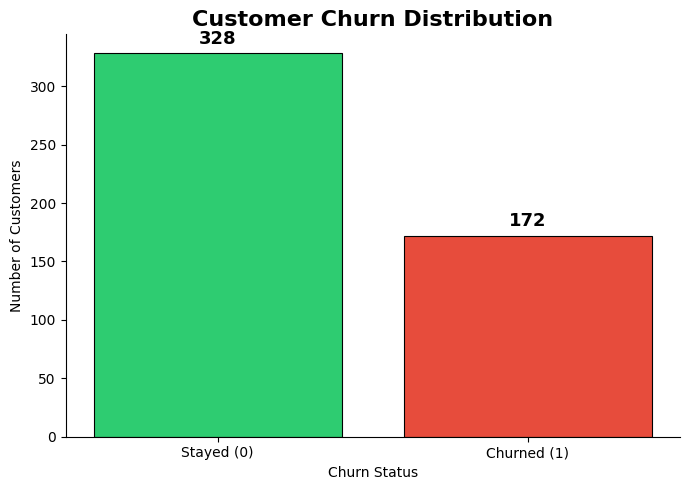

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(['Stayed (0)', 'Churned (1)'], churn_counts.values, color=colors, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val),
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_title('Customer Churn Distribution', fontsize=16, fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.set_xlabel('Churn Status')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### Correlation Heatmap

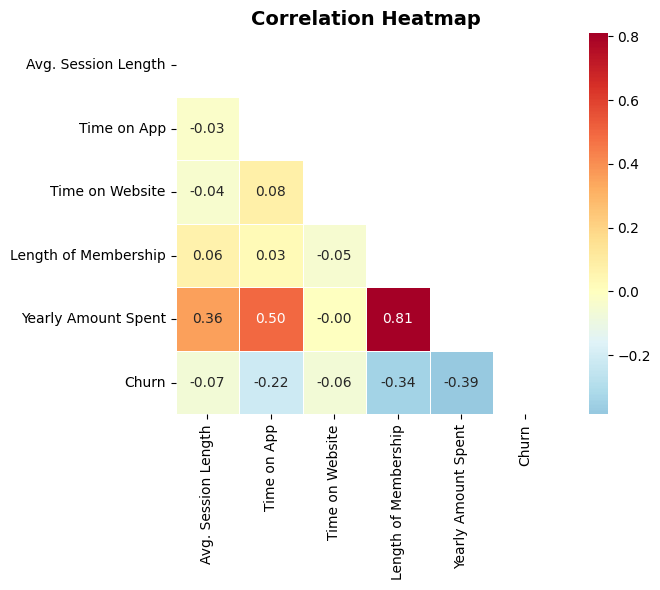

In [10]:
numeric_cols = ['Avg. Session Length', 'Time on App', 'Time on Website',
                'Length of Membership', 'Yearly Amount Spent', 'Churn']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [11]:
print("Correlation with Churn (sorted by absolute value):")
churn_corr = corr['Churn'].drop('Churn').abs().sort_values(ascending=False)
print(churn_corr)


Correlation with Churn (sorted by absolute value):
Yearly Amount Spent     0.385220
Length of Membership    0.339998
Time on App             0.216885
Avg. Session Length     0.067376
Time on Website         0.064311
Name: Churn, dtype: float64


### Step 4: Boxplots - Comparing Stayed vs Churned

/tmp/ipython-input-311/3456444450.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(
/tmp/ipython-input-311/3456444450.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(
/tmp/ipython-input-311/3456444450.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(


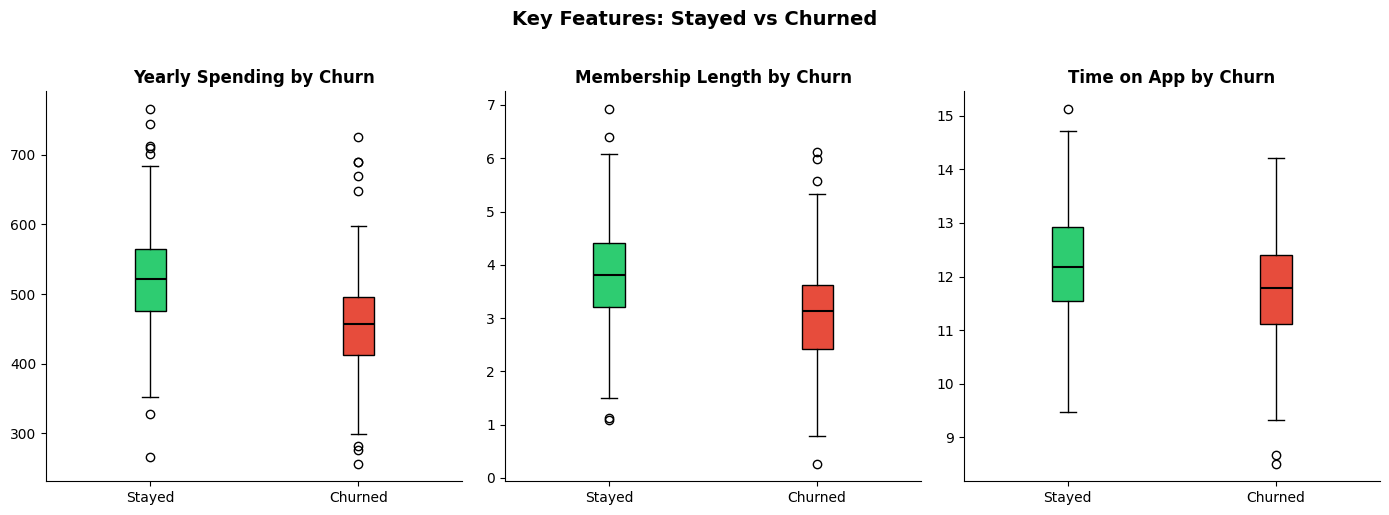

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
features_to_plot = ['Yearly Amount Spent', 'Length of Membership', 'Time on App']
titles = ['Yearly Spending by Churn', 'Membership Length by Churn', 'Time on App by Churn']

for idx, (feat, title) in enumerate(zip(features_to_plot, titles)):
    bp = axes[idx].boxplot(
        [df[df['Churn']==0][feat], df[df['Churn']==1][feat]],
        labels=['Stayed', 'Churned'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5)
    )
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

plt.suptitle('Key Features: Stayed vs Churned', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Part 2: Predictive Modeling


In [13]:
features = ['Avg. Session Length', 'Time on App', 'Time on Website',
            'Length of Membership', 'Yearly Amount Spent']
X = df[features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                      random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")


Training set: 375 rows
Test set: 125 rows


In [14]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)


In [15]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))


Accuracy: 0.7040

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.74      0.84      0.79        82
     Churned       0.59      0.44      0.51        43

    accuracy                           0.70       125
   macro avg       0.67      0.64      0.65       125
weighted avg       0.69      0.70      0.69       125



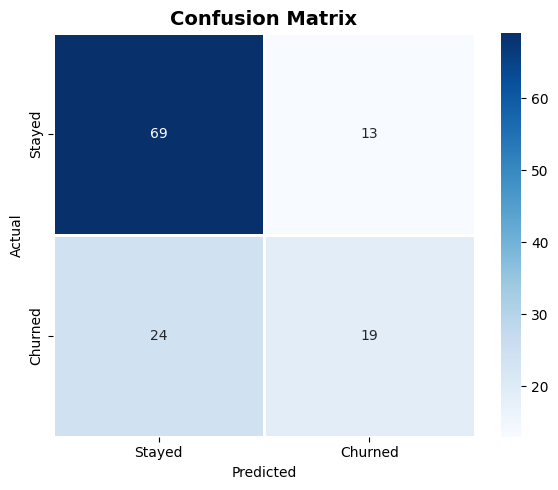

In [16]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'],
            linewidths=1, linecolor='white')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()


### Feature Importance

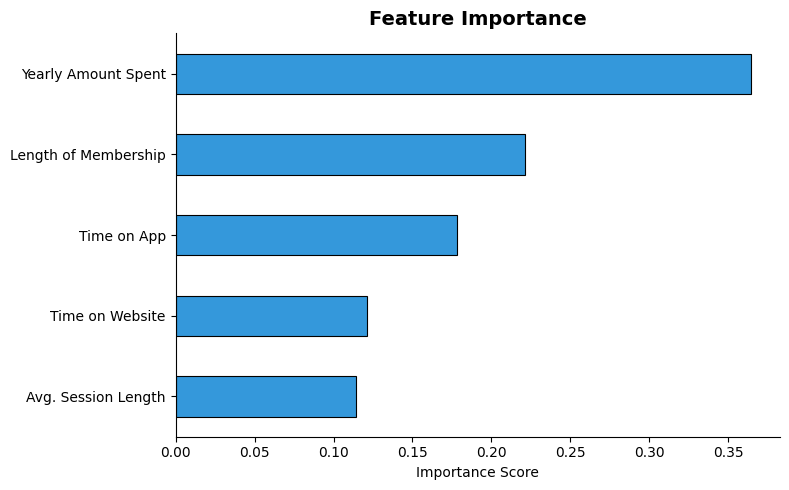

In [17]:
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', color='#3498db', edgecolor='black', linewidth=0.8, ax=ax)
ax.set_title('Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# Part 3: Text Analysis (NLP)


In [18]:
churned_reviews = df[df['Churn'] == 1]['customer_review']
print(f"Number of churned reviews: {len(churned_reviews)}")

# applying tf-idf
tfidf = TfidfVectorizer(max_features=30, stop_words='english', ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(churned_reviews)

# getting top keywords by average score
feature_names = tfidf.get_feature_names_out()
mean_scores = tfidf_matrix.mean(axis=0).A1
tfidf_scores = pd.Series(mean_scores, index=feature_names).sort_values(ascending=False)

print("Top 15 Complaint Keywords")
print(tfidf_scores.head(15))


Number of churned reviews: 172
Top 15 Complaint Keywords
experience     0.139302
customer       0.114888
quality        0.104064
website        0.095834
service        0.079476
took           0.078254
process        0.072789
app            0.065394
time           0.065394
terrible       0.061716
product        0.061562
arrived        0.051811
slow           0.049657
match shown    0.047456
match          0.047456
dtype: float64


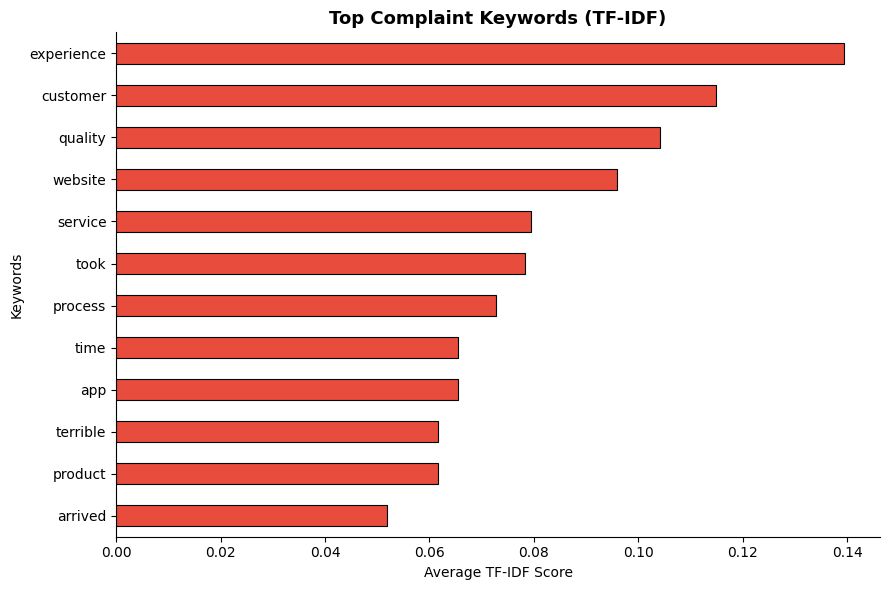

In [19]:
top_keywords = tfidf_scores.head(12).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
top_keywords.plot(kind='barh', color='#e74c3c', edgecolor='black', linewidth=0.8, ax=ax)
ax.set_title('Top Complaint Keywords (TF-IDF)', fontsize=13, fontweight='bold')
ax.set_xlabel('Average TF-IDF Score')
ax.set_ylabel('Keywords')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### Word Cloud

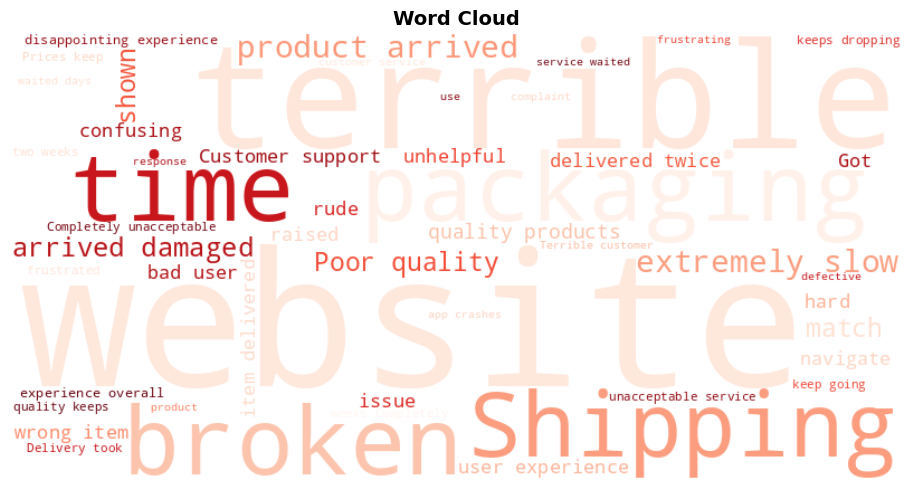

In [20]:
all_churned_text = ' '.join(churned_reviews)
wc = WordCloud(width=800, height=400, background_color='white',
               colormap='Reds', max_words=50, random_state=42)
wc.generate(all_churned_text)

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
